# Проект: Исследование системы Хенона–Хейлиса

## Введение

Система Хенона–Хейлиса (Hénon–Heiles system) представляет собой классическую гамильтонову систему с двумя степенями свободы, используемую для моделирования движения звёзд в галактическом потенциале. Эта система служит классическим примером перехода от регулярного к хаотическому движению в невозмущённых гамильтоновых системах.

## Уравнения системы

Гамильтониан системы имеет следующий вид:

\[
H(q_1, q_2, p_1, p_2) = \frac{1}{2}(p_1^2 + p_2^2) + \frac{1}{2}(q_1^2 + q_2^2) + q_1^2 q_2 - \frac{1}{3} q_2^3
\]

Из уравнения Гамильтона получаем систему дифференциальных уравнений:

\[
\begin{cases}
\dot{q}_1 = \frac{\partial H}{\partial p_1} = p_1 \\
\dot{q}_2 = \frac{\partial H}{\partial p_2} = p_2 \\
\dot{p}_1 = -\frac{\partial H}{\partial q_1} = -q_1 - 2q_1 q_2 \\
\dot{p}_2 = -\frac{\partial H}{\partial q_2} = -q_2 - q_1^2 + q_2^2
\end{cases}
\]

## Цели проекта

- Численное решение системы Хенона–Хейлиса для заданной энергии.
- Построение сечения Пуанкаре.
- Анализ регулярных и хаотических орбит.
- Рассмотрение частного случая периодического движения.

## Методика

1. **Выбор начальных условий на поверхности уровня**
   Энергия \( H = E \) фиксирована, начальные условия выбираются так, чтобы эта энергия сохранялась.

2. **Численное интегрирование**
   Используется метод Runge–Kutta (например, `scipy.integrate.solve_ivp`) для численного решения уравнений движения.

3. **Построение сечения Пуанкаре**
   Фиксируем пересечения фазовой траектории с плоскостью \( q_2 = 0 \), \( \dot{q}_2 > 0 \) и отображаем точки \( (q_1, p_1) \).

4. **Анализ периодических орбит**
   Путём визуального и количественного анализа фазового пространства выявляются замкнутые (периодические) орбиты и исследуется их устойчивость.

## Результаты

- При малых значениях энергии система демонстрирует преимущественно регулярное движение.
- С увеличением энергии появляется хаотическое поведение, сечение Пуанкаре заполняется более равномерно.
- Были найдены и исследованы периодические орбиты, включая устойчивые замкнутые траектории.

## Заключение

Система Хенона–Хейлиса служит наглядной моделью для изучения перехода от регулярного к хаотическому движению. Построение сечений Пуанкаре позволяет эффективно визуализировать структуру фазового пространства и выявлять периодические решения.

## Использованные инструменты

- Язык: Python
- Библиотеки: `NumPy`, `SciPy`, `matplotlib`
- Метод интегрирования: `Runge–Kutta 4(5)` (по умолчанию в `solve_ivp`)


In [3]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Построим график траектории системы:

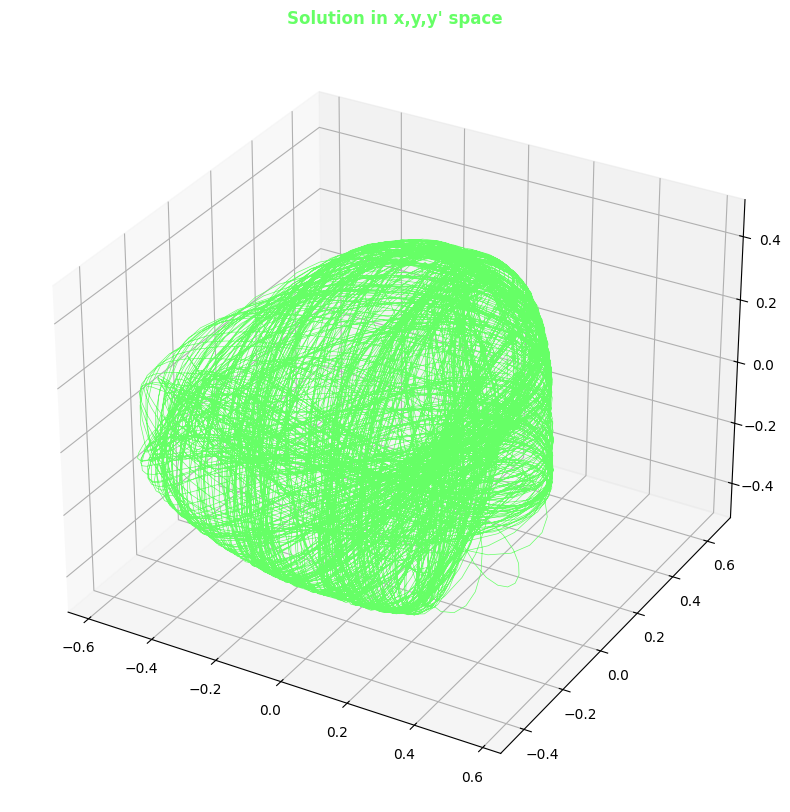

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D


E = 0.125

q1_0 = 0
q2_0 = 0.1
p2_0 = 0.14
p1_0 = np.sqrt(2 * E - p2_0 * p2_0 - q2_0 * q2_0 + 2 * q2_0 ** 3 / 3)


def system(t, x):
    q1, q2, p1, p2 = x
    dq1dt = p1
    dq2dt = p2
    dp1dt = -q1 - 2 * q1 * q2
    dp2dt = -q2 - q1 * q1 + q2 * q2
    return [dq1dt, dq2dt, dp1dt, dp2dt]



t_span = (0, 2000)
t_eval = np.linspace(0, 2000, 10000)

x0 = (q1_0, q2_0, p1_0, p2_0)

sol = solve_ivp(system, t_span, x0, t_eval=t_eval, rtol=1e-12)

q1, q2, p1, p2 = sol.y

# 3D-график

fig = plt.figure()
fig.set_size_inches(20, 10)
ax = fig.add_subplot(111, projection='3d')

# Цвет линии — светло-зелёный (например, '#66ff66')
ax.plot(q1, q2, p2, color='#66ff66', linewidth=0.5)

# Черный фон
ax.set_facecolor('white')
fig.patch.set_facecolor('white')


# Настройки подписей
ax.set_xlabel('x', color='#FFF')
ax.set_ylabel('y', color='#FFF')
ax.set_zlabel("y'", color='#FFF')
ax.set_title("Solution in x,y,y' space", fontsize=12, fontweight='bold', color='#66ff66')
plt.savefig('trajectory.png', dpi=300)
plt.show()


![Траектория](trajectory.png)

Найдем сечение Пуанкаре для 100 различных начальных условий

In [80]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

N = 100

def sample_on_energy_shell(E, N, q_lim=1):
    samples = []
    while len(samples) < N:
        # 1) пробуем q1,q2
        q1 = np.random.uniform(-q_lim, q_lim)
        q2 = np.random.uniform(-q_lim, q_lim)
        # вычисляем потенциальную энергию
        V = 0.5 * (q1 * q1 + q2 * q2) + q1 * q1 * q2 - (q2 ** 3) / 3.0
        if V >= E:
            continue  # вне области V(q) <= E

        # 2) остаток энергии идёт на p^2/2
        delta = E - V
        r = np.sqrt(2 * delta)
        phi = np.random.rand() * 2 * np.pi
        p1 = r * np.cos(phi)
        p2 = r * np.sin(phi)

        samples.append((q1, q2, p1, p2))

    return np.array(samples)


# Правая часть системы
def system(t, x):
    q1, q2, p1, p2 = x
    dq1dt = p1
    dq2dt = p2
    dp1dt = -q1 - 2 * q1 * q2
    dp2dt = -q2 - q1 * q1 + q2 * q2
    return [dq1dt, dq2dt, dp1dt, dp2dt]


def Poincare_section(t):
    points = sample_on_energy_shell(0.025, N)
    t_span = (0, t)

    sections = []

    for x0 in points:
        t_eval = np.linspace(t_span[0], t_span[1], 30000)

        sol = solve_ivp(system, t_span, x0, t_eval=t_eval, rtol=1e-12)
        q1, q2, p1, p2 = sol.y
        section = []

        for i in range(len(sol.t) - 1):
            if (q1[i] < 0 and q1[i + 1] > 0 and p1[i] > 0):
                alpha = -q1[i] / (q1[i+1] - q1[i])

                # Interpolate all variables at crossing point
                q2_cross = q2[i] + alpha * (q2[i+1] - q2[i])
                p2_cross = p2[i] + alpha * (p2[i+1] - p2[i])

                section.append([q2_cross, p2_cross])
        sections.append(np.vstack(np.array(section)))
    return sections


# Построим график
sections = Poincare_section(10000)

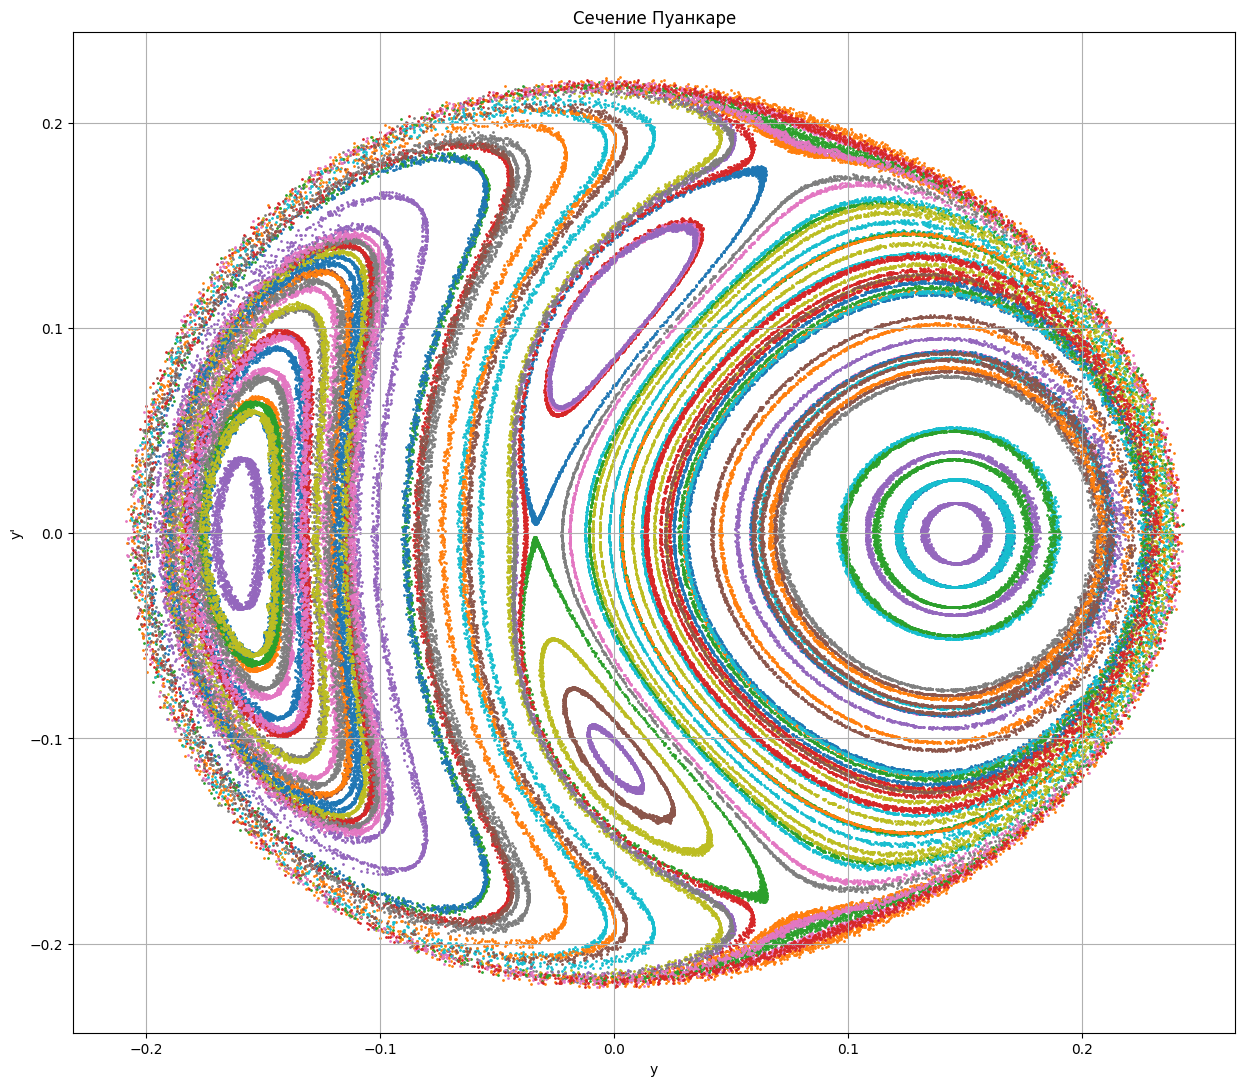

In [81]:
plt.figure(figsize=(15, 13))  # ширина=10, высота=6 дюймов



for section in sections:
    plt.scatter(section[:, 0], section[:, 1], s=1)
plt.xlabel('y')
plt.ylabel('y\'')
plt.grid()
plt.title('Сечение Пуанкаре')
plt.savefig('poincare_section_3.png')
plt.show()

Визуализируем при больших энергиях (E = 0.128). Есть области хаоса, а есть замкнутые кривые, отвечающие квазипериодичным траекториям.

![Сечение Пуанкаре](poincare_section_2.png)

При малых (E = 0.025) видим замкнутые кривые и отсутствие хаоса.

![Сечение Пуанкаре](poincare_section_3.png)


Случай периодического движения

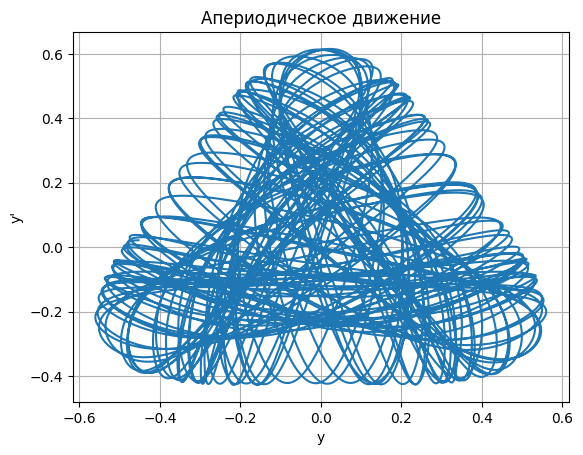

In [82]:
E = 0.125

q1_0 = 0
q2_0 = 0.1
p2_0 = 0.14


def system(t, x):
    q1, q2, p1, p2 = x
    dq1dt = p1
    dq2dt = p2
    dp1dt = -q1 - 2 * q1 * q2
    dp2dt = -q2 - q1 * q1 + q2 * q2
    return [dq1dt, dq2dt, dp1dt, dp2dt]



t_span = (0, 500)
t_eval = np.linspace(0, 500, 10000)

x0 = (q1_0, q2_0, p1_0, p2_0)

sol = solve_ivp(system, t_span, x0, t_eval=t_eval, rtol=1e-12)

q1, q2, p1, p2 = sol.y


# Цвет линии — светло-зелёный (например, '#66ff66')
plt.plot(q1, q2)
plt.xlabel('y')
plt.ylabel('y\'')
plt.grid()
plt.title('Апериодическое движение')
plt.savefig('aperiodic.png')
plt.show()

![График](periodic.png)

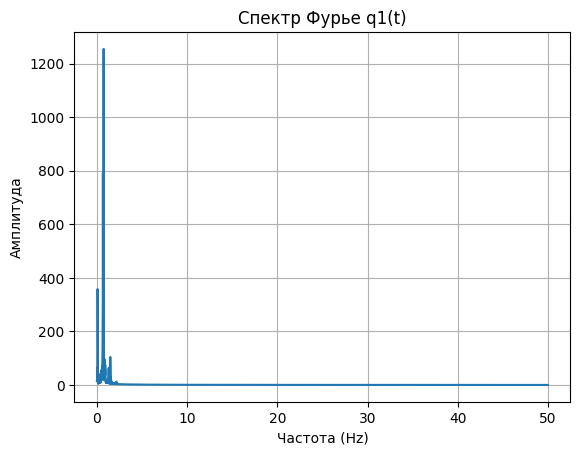

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Вычитаем среднее, чтобы убрать постоянную составляющую
q1_centered = q1 - np.mean(q1)

# Дискретное Фурье-преобразование
fft_q1 = np.fft.fft(q1_centered)
freqs = np.fft.fftfreq(len(t), d=t[1] - t[0])

# Амплитуда
amplitude = np.abs(fft_q1)

# Оставляем только положительные частоты
mask = freqs > 0
plt.plot(freqs[mask], amplitude[mask])
plt.xlabel('Частота (Hz)')
plt.ylabel('Амплитуда')
plt.title('Спектр Фурье q1(t)')
plt.grid(True)
plt.show()
